# Neural Network for ECG Classification



all lead ecg ml with resnet model



#### IMPORTS

In [1]:
import numpy as np

from dataloader import MyCustomDataset
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim

import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from selfeeg.models import ResNet1D


In [2]:
default_dir = os.getcwd()
def default_directory():
    os.chdir(f"{default_dir}")
    print(f"you are back to the default directory: {default_dir}")


In [3]:
default_directory()
os.getcwd()

you are back to the default directory: /home/karansingh/Documents/summer term/ECG_ML/MAIN


'/home/karansingh/Documents/summer term/ECG_ML/MAIN'

In [4]:
os.chdir("data_prep")
os.getcwd()

'/home/karansingh/Documents/summer term/ECG_ML/MAIN/data_prep'

In [5]:
# get list of all files in the directory
files = os.listdir()
print(files)

['README.md', 'data_prep.ipynb', 'EXPERIMENT_resnet', 'README copy', 'data_prep_for_only_one_disease.ipynb', 'unq_disease_SB.npy', 'disease_SB.npy', 'unq_disease_ST.npy', 'unq_disease_SR.npy', 'disease_ST.npy', 'disease_SR.npy', 'EXPERIMENT_2', 'EXPERIMENT_resnet_1d']


#### LOAD DATA

In [6]:
data_ST_list = np.load("unq_disease_ST.npy")
data_SB_list = np.load("unq_disease_SB.npy")
data_SR_list = np.load("unq_disease_SR.npy")
#print shape of all loaded files
print("shape of ST data: ", data_ST_list.shape)
print("shape of SB data: ", data_SB_list.shape)
print("shape of SR data: ", data_SR_list.shape)



shape of ST data:  (3000, 5000, 12)
shape of SB data:  (5000, 5000, 12)
shape of SR data:  (5000, 5000, 12)


### sanity check

In [7]:
# check the curupted data
def check_data(data):
    corrupted_indices = []
    for i in range(data.shape[0]):
        if np.isnan(data[i]).any() or np.isinf(data[i]).any():
            corrupted_indices.append(i)
    return corrupted_indices
corrupted_ST = check_data(data_ST_list)
corrupted_SB = check_data(data_SB_list)
corrupted_SR = check_data(data_SR_list)
print("corrupted ST indices: ", corrupted_ST)
print("corrupted SB indices: ", corrupted_SB)
print("corrupted SR indices: ", corrupted_SR)


corrupted ST indices:  [199, 306, 449, 633, 920, 2132, 2141, 2186, 2256]
corrupted SB indices:  [1418, 1852, 1898, 2756, 2881, 3007, 3101, 4091, 4192, 4293, 4376, 4594, 4601, 4720]
corrupted SR indices:  [149, 192, 213, 340, 385, 441, 2341, 2451, 2482, 2534, 4903, 4944]


In [8]:
# now che ck nana and inf difrently
def check_nan_inf(data):
    nan_indices = []
    inf_indices = []
    for i in range(data.shape[0]):
        if np.isnan(data[i]).any():
            nan_indices.append(i)
        if np.isinf(data[i]).any():
            inf_indices.append(i)
    return nan_indices, inf_indices
nan_ST, inf_ST = check_nan_inf(data_ST_list)
nan_SB, inf_SB = check_nan_inf(data_SB_list)
nan_SR, inf_SR = check_nan_inf(data_SR_list)
print("NaN ST indices: ", nan_ST)
print("Inf ST indices: ", inf_ST)
print("NaN SB indices: ", nan_SB)
print("Inf SB indices: ", inf_SB)
print("NaN SR indices: ", nan_SR)
print("Inf SR indices: ", inf_SR)


NaN ST indices:  [199, 306, 449, 633, 920, 2132, 2141, 2186, 2256]
Inf ST indices:  []
NaN SB indices:  [1418, 1852, 1898, 2756, 2881, 3007, 3101, 4091, 4192, 4293, 4376, 4594, 4601, 4720]
Inf SB indices:  []
NaN SR indices:  [149, 192, 213, 340, 385, 441, 2341, 2451, 2482, 2534, 4903, 4944]
Inf SR indices:  []


In [9]:
# remove corrupted data from all three datasets
def remove_corrupted_data(data_list, corrupted_indices):
    return np.delete(data_list, corrupted_indices, axis=0)
    return cleaned_data

data_ST_list = remove_corrupted_data(data_ST_list, nan_ST + inf_ST)
data_SB_list = remove_corrupted_data(data_SB_list, nan_SB + inf_SB)
data_SR_list = remove_corrupted_data(data_SR_list, nan_SR + inf_SR)

### creating batches


In [10]:

# lead 1


# Use single channel (lead 1) for training and testing
data_ST_list = data_ST_list[:, :, 0:1]  # shape: (N_ST, T, 1)
data_SB_list = data_SB_list[:, :, 0:1]  # shape: (N_SB, T, 1)
data_SR_list = data_SR_list[:, :, 0:1]  # shape: (N_SR, T, 1)
images = data_ST_list          # shape: (N_ST, T, 1)
labels = np.zeros(images.shape[0])

# SB
images = np.concatenate((images, data_SB_list), axis=0)
labels = np.concatenate((labels, np.ones(data_SB_list.shape[0])))

# SR
images = np.concatenate((images, data_SR_list), axis=0)
labels = np.concatenate((labels, 2*np.ones(data_SR_list.shape[0])))

print("we have", images.shape[0], "samples and", labels.shape[0], "labels")
print("raw shape:", images.shape)

                    

we have 12965 samples and 12965 labels
raw shape: (12965, 5000, 1)


In [11]:
len(images),len(labels)

(12965, 12965)

In [12]:
from sklearn.model_selection import train_test_split

X = images        # (12965, 5000, 12)
y = labels      # (12965,)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

#split is of 70% train, 15% val, 15% test


In [13]:
# compute stats on TRAIN set only
mean = X_train.mean(axis=(0, 1))   # (12,)
std  = X_train.std(axis=(0, 1))    # (12,)

std[std < 1e-6] = 1e-6  # safety


In [14]:
# apply normalization
X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std


#### transposing data

In [15]:
# (batch, time, channels) → (batch, channels, time)
X_train = X_train.transpose(0, 2, 1)
X_val   = X_val.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)


In [16]:
import torch
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_dataloader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dataloader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_dataloader  = DataLoader(test_ds, batch_size=32, shuffle=False)

#### CREATE BATCHES

In [17]:
# # 70% train, 15% val, 15% test split
# images_train, images_temp, labels_train, labels_temp = train_test_split(
#     images, labels, train_size=0.70, random_state=42
# )
# images_val, images_test, labels_val, labels_test = train_test_split(
#     images_temp, labels_temp, test_size=0.5, random_state=42
# )

# train_dataset = MyCustomDataset_resnet(images_train, labels_train)
# val_dataset   = MyCustomDataset_resnet(images_val, labels_val)
# test_dataset  = MyCustomDataset_resnet(images_test, labels_test)

# train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# val_dataloader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
# test_dataloader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


## model


#### TRAINING PARAMETERS

#### TRAINING

# 1D resnet

In [18]:
model = ResNet1D(
    nb_classes=3,
    Chans=1,
    Samples=1000,
    Layers=[2, 2, 2, 2],   # same as your 4 layers with 2 blocks each
    inplane=32,             # equivalent to base_channels=32
    kernLength=7
)

In [19]:
x, y = next(iter(train_dataloader))
print(x.shape)

torch.Size([32, 1, 5000])


In [20]:
default_directory()
import copy
import torch
import torch.nn as nn
import numpy as np
import os
import time
from datetime import datetime
from IPython.display import clear_output
import importlib, plots
importlib.reload(plots)
from plots import evaluate_all
from seed_utils import set_seed, SEEDS


# ── 1. Setup multi-seed tracking ──
all_metrics = []
all_histories = []

log_dir = "EXPERIMENT_resnet_1d_selfeeg_typ1_singlelead1_randomseed"
os.makedirs(log_dir, exist_ok=True)

# Try getting notebook name
try:
    from IPython import get_ipython
    notebook_name = get_ipython().user_ns.get('__vsc_ipynb_file__', None)
    if notebook_name is None:
        import ipynbname
        notebook_name = ipynbname.name()
    notebook_name = os.path.splitext(os.path.basename(notebook_name))[0]
except:
    notebook_name = "main__resnet_1d_selfeeg_singlelead_typ1"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def log_print(msg, f):
    print(msg)
    f.write(msg + "\n")
    f.flush()

# ── 2. Loop through seeds ──
for seed in SEEDS:
    namkaran = f"resnet_1d_selfeeg_lr1e-3_seed{seed}"
    log_path = os.path.join(log_dir, f"{notebook_name}_{namkaran}.txt")
    
    # Use our seed utility!
    set_seed(seed)

    with open(log_path, "a") as f:
        log_print("\n" + "="*60, f)
        log_print(f"Training Run Started for Seed {seed}: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", f)
        log_print("="*60, f)

        # Initialize model inside loop to reset weights!
        model = ResNet1D(nb_classes=3, Chans=1, Samples=5000, Layers=[2,2,2,2], inplane=32, kernLength=7).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2
        )

        def correct(pred, true):
            return (pred == true).sum().item()

        train_losses_list, val_losses_list = [], []
        accuracy_train_list, accuracy_val_list = [], []
        best_acc, wait, best_model = 0, 0, None
        num_epochs, patience = 25, 7
        total_start_time = time.time()

        for epoch in range(num_epochs):
            epoch_start_time = time.time()
            
            # --- Train ---
            model.train()
            run_loss = 0
            c_train = t_train = 0
            train_start_time = time.time()
            for x, y in train_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                run_loss += loss.item()
                c_train += correct(out.argmax(1), y)
                t_train += y.size(0)

            train_time = time.time() - train_start_time
            train_losses_list.append(run_loss / len(train_dataloader))
            accuracy_train_list.append(100 * c_train / t_train)

            # --- Validation ---
            model.eval()
            run_loss = 0
            c_val = t_val = 0
            val_start_time = time.time()
            with torch.no_grad():
                for x, y in val_dataloader:
                    x, y = x.to(device), y.to(device)
                    out = model(x)
                    loss = criterion(out, y)
                    run_loss += loss.item()
                    c_val += correct(out.argmax(1), y)
                    t_val += y.size(0)

            val_time = time.time() - val_start_time
            val_losses_list.append(run_loss / len(val_dataloader))
            accuracy_val_list.append(100 * c_val / t_val)

            # --- LR scheduler ---
            old_lr = optimizer.param_groups[0]["lr"]
            scheduler.step(val_losses_list[-1])
            lr_now = optimizer.param_groups[0]["lr"]
            
            if lr_now != old_lr:
                log_print(f"  >> Learning rate reduced: {old_lr:.6f} -> {lr_now:.6f}", f)

            # --- Early stopping ---
            if accuracy_val_list[-1] > best_acc:
                best_acc, wait = accuracy_val_list[-1], 0
                best_model = copy.deepcopy(model.state_dict())
            else:
                wait += 1
                if wait >= patience:
                    log_print(f"## Early stopping at epoch {epoch + 1} ##", f)
                    break

            epoch_time = time.time() - epoch_start_time
            log_print(
                f"Epoch [{epoch + 1}/{num_epochs}] | "
                f"Train Loss: {train_losses_list[-1]:.4f}, Val Loss: {val_losses_list[-1]:.4f}, "
                f"Train Acc: {accuracy_train_list[-1]:.2f}%, Val Acc: {accuracy_val_list[-1]:.2f}%, "
                f"LR: {lr_now:.6f} | "
                f"Time: {epoch_time:.2f}s", f
            )

        total_training_time = time.time() - total_start_time

        # Restore best weights and save
        model.load_state_dict(best_model)
        torch.save(best_model, os.path.join(log_dir, f"{notebook_name}_{namkaran}.pth"))
        log_print(f"\nBest Validation Accuracy: {best_acc:.2f}%", f)

        log_print("="*60, f)
        log_print(f"Total Training Time: {total_training_time:.2f}s", f)
        
        # ── 3. Evaluate the seed silently and store results ──
        log_print(f"Evaluating best model on test set for seed {seed}...", f)
        results = evaluate_all(
            model, test_dataloader, device,
            plot_confusion_matrix=False,
            plot_pr_micro=False,
            plot_pr_per_class=False,
            plot_roc=False,
            print_report=False
        )
        all_metrics.append(results)
        
        history = {
            "train_acc": accuracy_train_list,
            "val_acc": accuracy_val_list,
            "train_loss": train_losses_list,
            "val_loss": val_losses_list
        }
        all_histories.append(history)

print("\n ALL 5 SEEDS COMPLETED!")

you are back to the default directory: /home/karansingh/Documents/summer term/ECG_ML/MAIN

Training Run Started for Seed 40: 2026-07-03 02:15:51
Epoch [1/25] | Train Loss: 0.2920, Val Loss: 0.2002, Train Acc: 88.56%, Val Acc: 93.11%, LR: 0.001000 | Time: 21.41s
Epoch [2/25] | Train Loss: 0.1615, Val Loss: 0.1240, Train Acc: 94.30%, Val Acc: 95.63%, LR: 0.001000 | Time: 21.28s
Epoch [3/25] | Train Loss: 0.1346, Val Loss: 0.1463, Train Acc: 95.25%, Val Acc: 95.73%, LR: 0.001000 | Time: 21.33s
Epoch [4/25] | Train Loss: 0.1249, Val Loss: 0.1161, Train Acc: 95.69%, Val Acc: 96.66%, LR: 0.001000 | Time: 21.35s
Epoch [5/25] | Train Loss: 0.1049, Val Loss: 0.0946, Train Acc: 96.19%, Val Acc: 96.97%, LR: 0.001000 | Time: 21.37s
Epoch [6/25] | Train Loss: 0.1028, Val Loss: 0.2024, Train Acc: 96.20%, Val Acc: 93.98%, LR: 0.001000 | Time: 21.38s
Epoch [7/25] | Train Loss: 0.1000, Val Loss: 0.0776, Train Acc: 96.50%, Val Acc: 97.17%, LR: 0.001000 | Time: 21.38s
Epoch [8/25] | Train Loss: 0.0972, V


  MULTI-SEED SUMMARY  (5 seeds: 40–44)
Metric                     Mean        Std
------------------------------------------
  accuracy               98.03% ± 0.24%     
  f1_macro               0.9799 ± 0.0023    
  f1_micro               0.9803 ± 0.0024    
  auc_macro              0.9981 ± 0.0008    
  ap_micro               0.9972 ± 0.0011    
----------------------------------------------------------------------------------------------------
  PER-CLASS CLASSIFICATION REPORT (Mean ± Std)
----------------------------------------------------------------------------------------------------
  Class           Precision            Recall               F1-Score             AUC                  Support
----------------------------------------------------------------------------------------------------
  ST              0.9629 ± 0.0051      0.9924 ± 0.0023      0.9774 ± 0.0026      0.9982 ± 0.0006      449.0
  SB              0.9876 ± 0.0080      0.9874 ± 0.0108      0.9874 ± 0.0025      

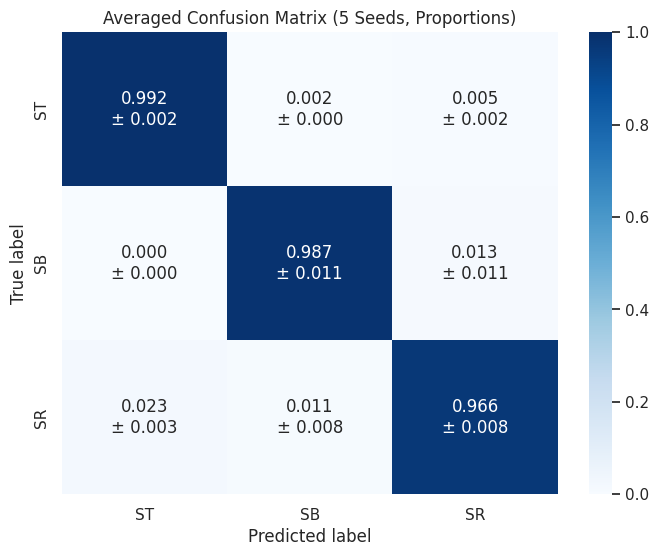

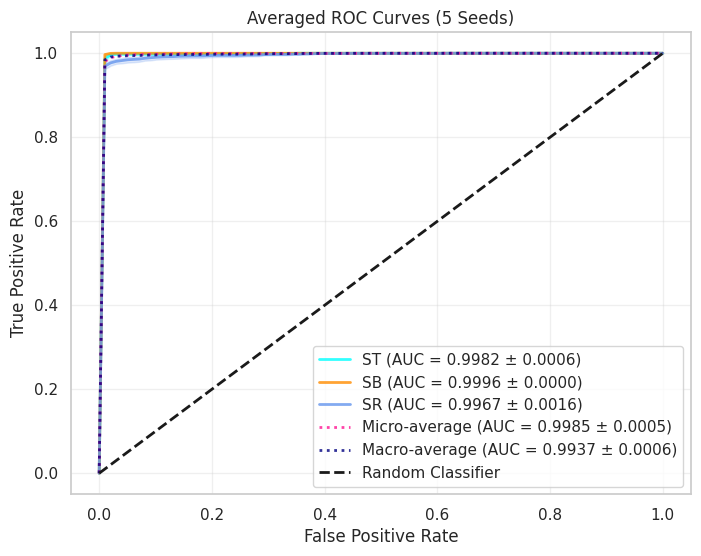

AUC Scores (Mean ± Std):
------------------------------
Class ST: 0.9982 ± 0.0006
Class SB: 0.9996 ± 0.0000
Class SR: 0.9967 ± 0.0016
Micro-average: 0.9985 ± 0.0005
Macro-average: 0.9937 ± 0.0006
------------------------------



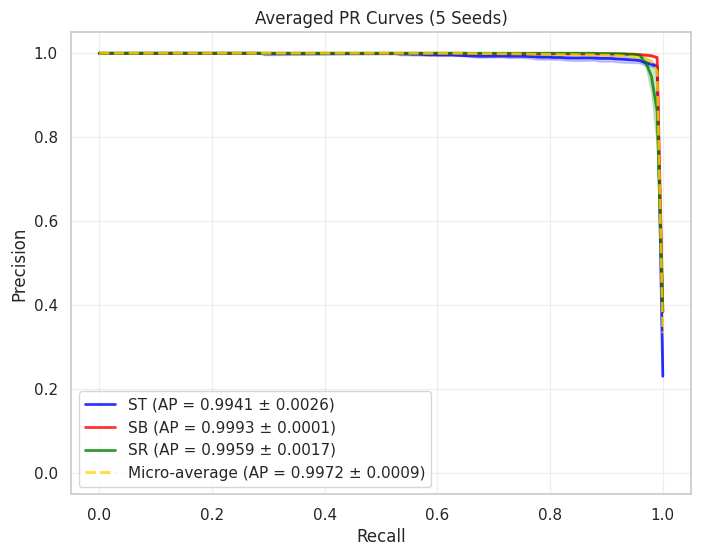

Saved: EXPERIMENT_resnet_1d_selfeeg_typ1_singlelead1_randomseed/resnet_1d_selfeeg_lr1e-3_seed44_val_acc_multiseed.png


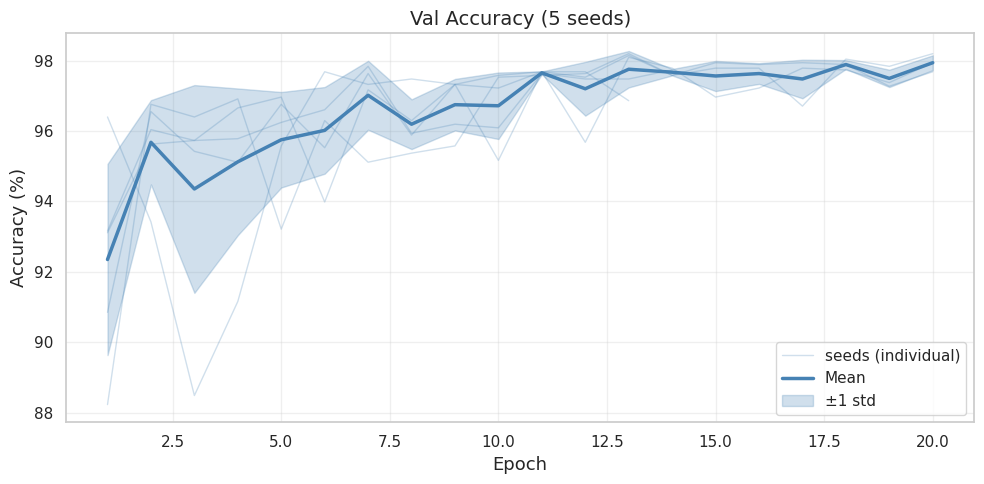

Saved: EXPERIMENT_resnet_1d_selfeeg_typ1_singlelead1_randomseed/resnet_1d_selfeeg_lr1e-3_seed44_val_loss_multiseed.png


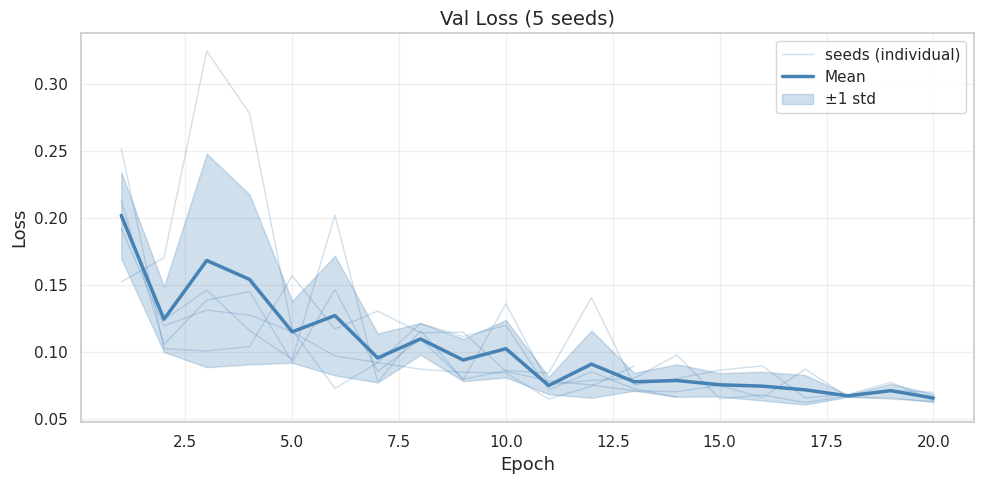

In [23]:
import importlib, plots
importlib.reload(plots)
from plots import plot_learning_curves_multiseed, summarize_seed_results, evaluate_multiseed_plots

# 1. Prints the classification report table and saves the CSV
summarize_seed_results(
    all_metrics,
    save_csv=os.path.join(log_dir, f"{namkaran}_multiseed_summary.csv"),
)

# 2. Plots and saves Averaged CM (Proportions), ROC (+ text AUCs), and PR curves
evaluate_multiseed_plots(
    all_metrics, 
    class_names=["ST", "SB", "SR"],
    save_dir=log_dir,
    namkaran=namkaran
)

# 3. Plots and saves Learning Curves (Accuracy & Loss)
plot_learning_curves_multiseed(
    all_histories, metric="val_acc",
    title=f"Val Accuracy (5 seeds)",
    save_path=os.path.join(log_dir, f"{namkaran}_val_acc_multiseed.png"),
)
plot_learning_curves_multiseed(
    all_histories, metric="val_loss",
    title=f"Val Loss (5 seeds)",
    save_path=os.path.join(log_dir, f"{namkaran}_val_loss_multiseed.png"),
)


In [22]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 2,442,915
Trainable parameters: 2,442,915
